In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import seaborn as sns
from matplotlib.patches import Rectangle

In [2]:
def show_palette(pal):
    sns.set(palette=pal)
    current_palette = sns.color_palette()
    sns.palplot(current_palette)

In [3]:

def geo_mean(iterable):
    a = np.array(iterable)
    b = a != 0
    a = a[b]
    b = a != np.inf
    a = a[b]
    return a.prod()**(1.0/len(a))

In [4]:
colors = ["#FF85CA", "#8ADD67", "#F6CC58", "#60D3FF", "#2e578c"]
#colors = ['#F4B183', '#FFD966', '#BDD7EE', '#C5E0B4']
sns.set_palette(colors)

In [5]:
plt.rcParams['font.sans-serif'] = ['Times New Roman']

In [6]:
X_NAMES = ["3070 Ti", "4070 Ti Super", "V100", "A100", "3070 Ti", "4070 Ti Super", "V100", "A100"]
LEGENDS = ['SOTA Reversible Models', 'Gradient Checkpoint', 'Reversyn']
sota = [0.587, 0.533, 0.545, 0.541, 0.582, 0.634, 0.612, 0.624]
checkpoint = [0.791, 0.756, 0.727, 0.731, 0.678, 0.617, 0.591, 0.587] # large mem better saving, due to fragmentation
reversyn = [0.982, 0.906, 0.927, 0.847, 0.499, 0.493, 0.504, 0.512] # rev and sota revs no fragmentation.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'sans-serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'sans-serif' not found because none of the following families were found: Times New Roman
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not

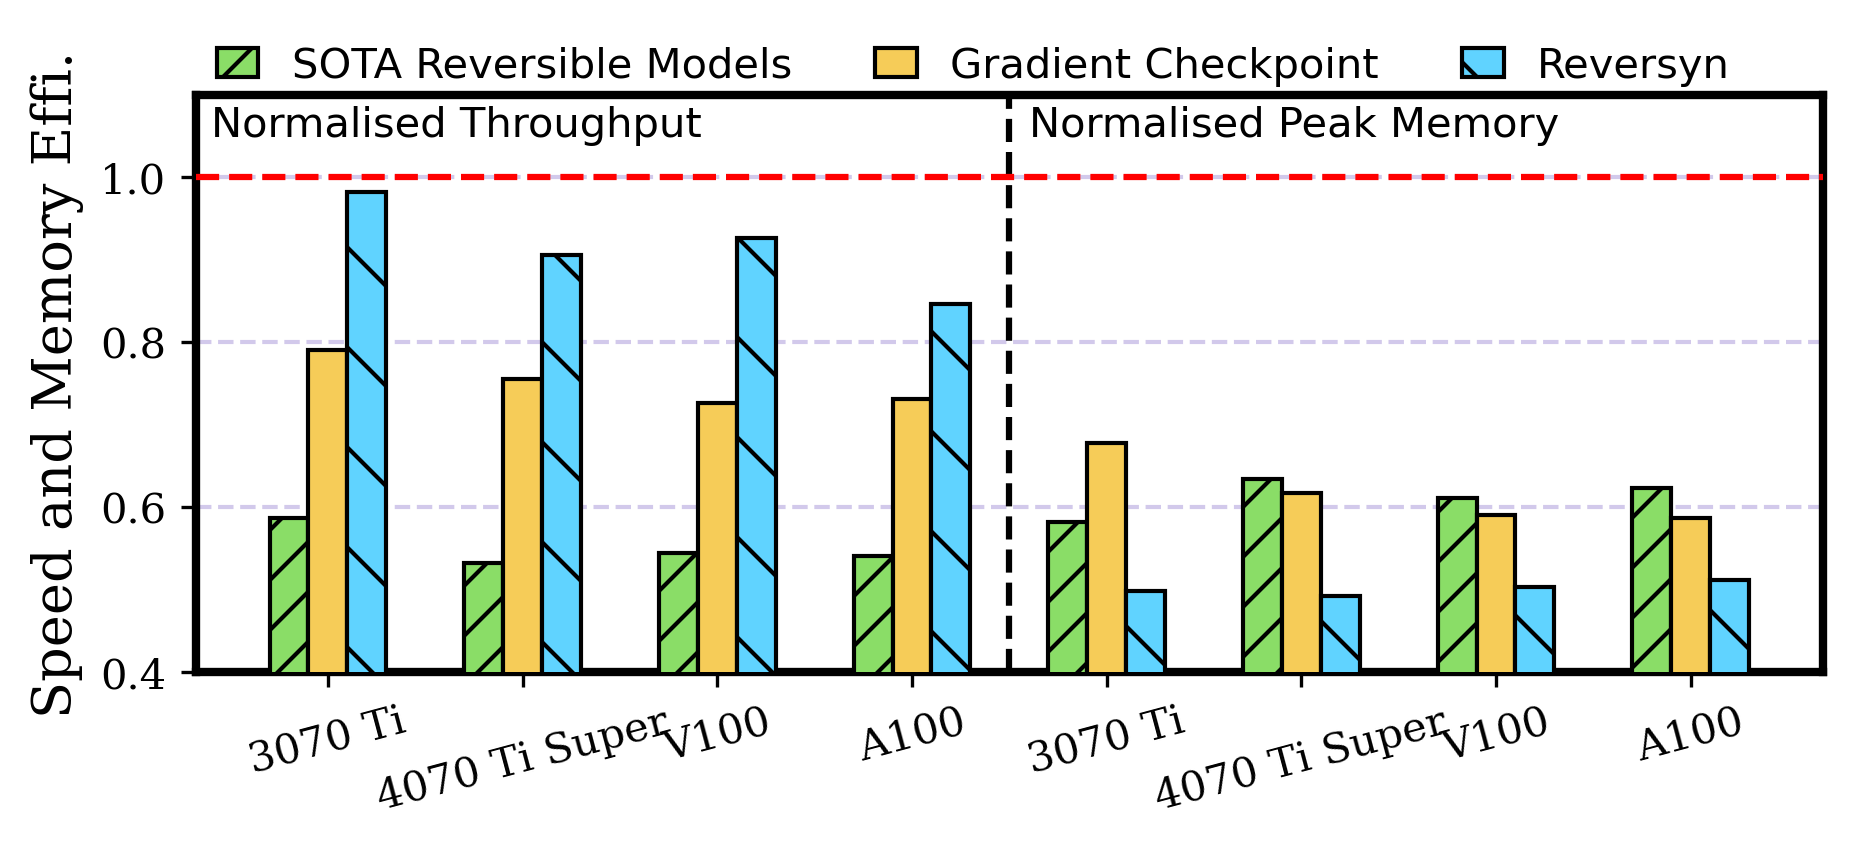

In [8]:
# 设置柱状图的位置和宽度
n = len(X_NAMES)
width = 0.2
ind = np.arange(n)
line_width = 1

# 创建柱状图
fig, ax = plt.subplots(figsize=(7,2.5), dpi=300)
rects1 = ax.bar(ind - width, sota, width, label='SOTA Reversible Models',color=colors[1],edgecolor='black', linewidth=line_width,zorder=10, hatch='//')
rects3 = ax.bar(ind, checkpoint, width, label='Gradient Checkpoint',color=colors[2],edgecolor='black', linewidth=line_width,zorder=10)
rects2 = ax.bar(ind + width, reversyn, width, label='Reversyn',color=colors[3],edgecolor='black', linewidth=line_width,zorder=10, hatch='\\')


plt.grid(axis="y", c='#d2c9eb',linewidth=line_width,linestyle = '--',zorder=0)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.set_ylim(0.4, 1.1)

ax.axhline(y=1.0, color='r', linestyle='--', zorder=11)
# 中间灰色的分割线
ax.axvline(x=3.5, linestyle='--', color='black')
# 右边的字
ax.text(-0.6, 1.05, 'Normalised Throughput', ha='left')
ax.text(3.6, 1.05, 'Normalised Peak Memory', ha='left')

# 在数据为0的地方标上红色的叉叉
for i, value in enumerate(sota):
    if value == 0:
        ax.scatter(i - width, 0.1, color='red', marker='x', zorder = 12)
for i, value in enumerate(checkpoint):
    if value == 0:
        ax.scatter(i, 0.1, color='red', marker='x',zorder=12)
for i, value in enumerate(reversyn):
    if value == 0:
        ax.scatter(i+ width, 0.1, color='red', marker='x',zorder=12)

# 设置图例的字体，ncol = 2 表示图例要放两列
plt.legend(prop={'family' : 'Times New Roman', 'size': 10}, ncol = 10,frameon=False, loc='upper left',handlelength=1,bbox_to_anchor=(-0.01, 1.15))

#设置X轴，Y轴标签的字体及大小
# x_len表示X轴的标签写在哪个坐标位置，有事可能x_len有变差，需要手动调一下他的值，不过偏差不会很大
plt.xticks(ind, X_NAMES, fontproperties='DejaVu Serif', rotation=15)
plt.yticks(fontproperties='DejaVu Serif')
# plt.margins(x=0.03)
# plt.xlabel("", fontproperties='Times New Roman',fontsize=10)
# plt.ylabel("Normalised Performance",fontproperties='DejaVu Serif')
# plt.tick_params(axis="x", which="both", pad=30)
# plt.xlabel("", fontproperties='Times New Roman',fontsize=10)
plt.ylabel("Speed and Memory Effi.",fontproperties='DejaVu Serif', fontsize=13)
# plt.tight_layout(marginw)
# plt.show()
plt.savefig("across-devs.pdf",bbox_inches='tight')
